In [1]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("prepared_data.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'Age', 'Gender_Female', 'Gender_Male',
       'Education_Bachelor', 'Education_HSC', 'Education_Master',
       'Education_PhD', 'Education_SSC', 'Industry_Education',
       'Industry_Finance', 'Industry_Healthcare', 'Industry_Marketing-Media',
       'Industry_Others', 'Industry_Student', 'Industry_Technology-IT',
       'AI_Knowledge_Beginner', 'AI_Knowledge_Expert',
       'AI_Knowledge_Intermediate', 'AI_Usage_Daily',
       'AI_Usage_Monthly- A few times', 'AI_Usage_Never',
       'AI_Usage_Weekly- A few times', 'AI_Helpfulness_Maybe',
       'AI_Helpfulness_No', 'AI_Helpfulness_Yes', 'AI_Concern_Maybe',
       'AI_Concern_No', 'AI_Concern_Yes', 'Alexa', 'ChatGPT', 'Deep Seek',
       'Gemini', 'Google Assistant', 'Grammarly', 'None-above', 'Notion-AI',
       'Siri', 'Unnamed: 38', 'Assignment', 'Automation', 'Coding',
       'Data-Analysis', 'Education', 'Medical', 'Personal-Use',
       'Project works', 'Translation, Presentation, Severel Writings',
      

# H1

In [4]:
# Predictor
X = df[['Age', 'Gender_Female', 'Gender_Male',
       'Education_Bachelor', 'Education_HSC', 'Education_Master',
       'Education_PhD', 'Education_SSC',"Industry_Education", "Industry_Student", 'AI_Knowledge_Beginner', 'AI_Knowledge_Expert',
       'AI_Knowledge_Intermediate', 'AI_Usage_Daily',
       'AI_Usage_Monthly- A few times', 'AI_Usage_Never',
       'AI_Usage_Weekly- A few times']]
X = sm.add_constant(X)

In [5]:
# Outcome: AI Trust (AI_Helpfulness_Yes)
y_trust = df["AI_Helpfulness_Yes"]

In [6]:
model_trust = sm.Logit(y_trust, X).fit()
print("\n=== TRUST MODEL ===")
print(model_trust.summary())

         Current function value: 0.599766
         Iterations: 35

=== TRUST MODEL ===
                           Logit Regression Results                           
Dep. Variable:     AI_Helpfulness_Yes   No. Observations:                  220
Model:                          Logit   Df Residuals:                      205
Method:                           MLE   Df Model:                           14
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                  0.1245
Time:                        00:04:10   Log-Likelihood:                -131.95
converged:                      False   LL-Null:                       -150.71
Covariance Type:            nonrobust   LLR p-value:                 0.0006163
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             5.0854   1.41e+07   3.61e-07      1.000   -2.76e+07

C:\Users\ashik\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
# Outcome: AI Concern (AI_Concern_Yes)
y_concern = df["AI_Concern_Yes"]

In [8]:
model_concern = sm.Logit(y_concern, X).fit()
print("\n=== CONCERN MODEL ===")
print(model_concern.summary())

         Current function value: 0.414366
         Iterations: 35

=== CONCERN MODEL ===
                           Logit Regression Results                           
Dep. Variable:         AI_Concern_Yes   No. Observations:                  220
Model:                          Logit   Df Residuals:                      205
Method:                           MLE   Df Model:                           14
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                  0.1719
Time:                        00:05:18   Log-Likelihood:                -91.160
converged:                      False   LL-Null:                       -110.09
Covariance Type:            nonrobust   LLR p-value:                 0.0005466
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -3.2750        nan        nan        nan         n

C:\Users\ashik\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


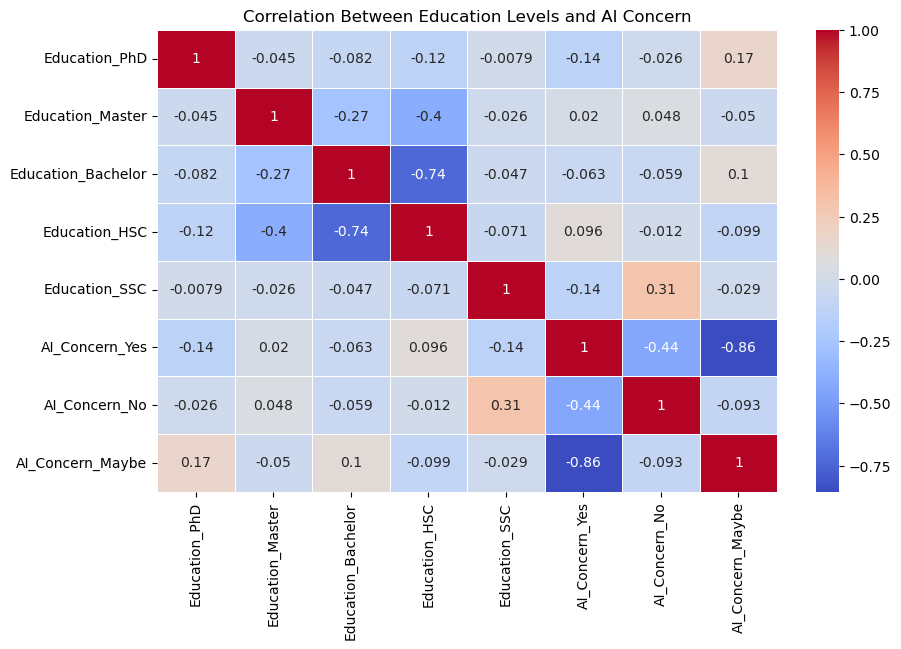

In [9]:
# Select all education-related columns + concern columns
education_cols = ["Education_PhD", "Education_Master", "Education_Bachelor", "Education_HSC", "Education_SSC"
]

concern_cols = ["AI_Concern_Yes", "AI_Concern_No", "AI_Concern_Maybe"
]

# Combine the columns
corr_data = df[education_cols + concern_cols]

# Compute correlations
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Education Levels and AI Concern")
plt.show()

# H2

In [32]:
# Predictor
X = df[['Age', 'Gender_Female', 'Gender_Male',
      'Industry_Finance', 'Industry_Healthcare', 'Industry_Marketing-Media',
       'Industry_Others', 'Industry_Student', 'Industry_Technology-IT', 'AI_Knowledge_Expert',
       'AI_Knowledge_Intermediate', 'AI_Usage_Daily',
       'AI_Usage_Monthly- A few times', 'AI_Usage_Never',
       'AI_Usage_Weekly- A few times']]
X = sm.add_constant(X)

In [33]:
# Outcome: AI Trust (AI_Helpfulness_Yes)
y_trust = df["AI_Helpfulness_Yes"]

In [34]:
model_trust = sm.Logit(y_trust, X).fit()
print("\n=== TRUST MODEL ===")
print(model_trust.summary())

         Current function value: 0.620453
         Iterations: 35

=== TRUST MODEL ===
                           Logit Regression Results                           
Dep. Variable:     AI_Helpfulness_Yes   No. Observations:                  220
Model:                          Logit   Df Residuals:                      206
Method:                           MLE   Df Model:                           13
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                 0.09426
Time:                        00:45:52   Log-Likelihood:                -136.50
converged:                      False   LL-Null:                       -150.71
Covariance Type:            nonrobust   LLR p-value:                  0.007925
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -0.9900        nan        nan        nan         nan

C:\Users\ashik\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [35]:
# Outcome: AI Concern (AI_Concern_Yes)
y_concern = df["AI_Concern_Yes"]

In [36]:
model_concern = sm.Logit(y_concern, X).fit()
print("\n=== CONCERN MODEL ===")
print(model_concern.summary())

         Current function value: 0.432968
         Iterations: 35

=== CONCERN MODEL ===
                           Logit Regression Results                           
Dep. Variable:         AI_Concern_Yes   No. Observations:                  220
Model:                          Logit   Df Residuals:                      206
Method:                           MLE   Df Model:                           13
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.1348
Time:                        00:46:58   Log-Likelihood:                -95.253
converged:                      False   LL-Null:                       -110.09
Covariance Type:            nonrobust   LLR p-value:                  0.005251
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             0.5836        nan        nan        nan         n

C:\Users\ashik\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# H3

C:\Users\ashik\AppData\Local\Temp\ipykernel_1936\4235447809.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Usage", y="Proportion_Not_Concerned", data=plot_df, palette="viridis")


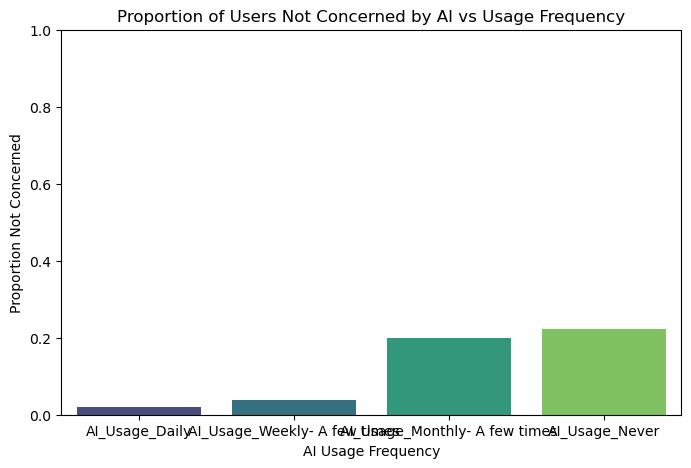

In [38]:
# AI usage columns
usage_cols = [
    "AI_Usage_Daily",
    "AI_Usage_Weekly- A few times",
    "AI_Usage_Monthly- A few times",
    "AI_Usage_Never"
]

# Compute proportion of "Not Concerned" for each usage
proportions = {}
for col in usage_cols:
    subset = df[df[col] == 1]  # users with this usage
    prop = subset["AI_Concern_No"].mean()  # proportion not concerned
    proportions[col] = prop

# Convert to dataframe for plotting
plot_df = pd.DataFrame({
    "Usage": list(proportions.keys()),
    "Proportion_Not_Concerned": list(proportions.values())
})

# --- Bar plot ---
plt.figure(figsize=(8,5))
sns.barplot(x="Usage", y="Proportion_Not_Concerned", data=plot_df, palette="viridis")
plt.ylim(0,1)
plt.title("Proportion of Users Not Concerned by AI vs Usage Frequency")
plt.ylabel("Proportion Not Concerned")
plt.xlabel("AI Usage Frequency")
plt.show()

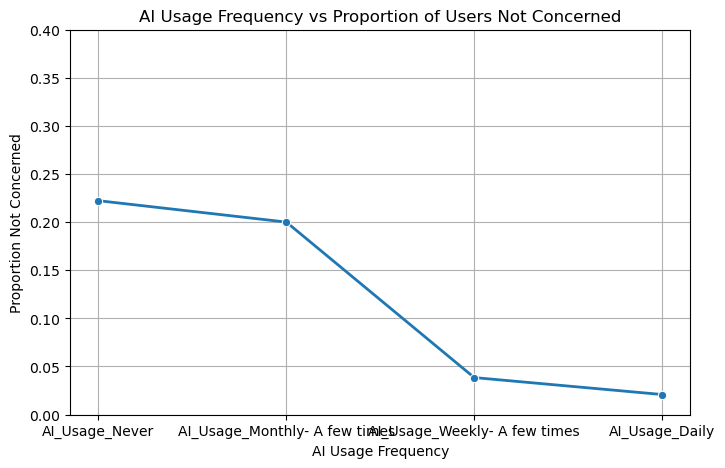

In [41]:
# AI usage columns
usage_cols = [
    "AI_Usage_Never",
    "AI_Usage_Monthly- A few times",
    "AI_Usage_Weekly- A few times",
    "AI_Usage_Daily"
]

# Compute proportion of "Not Concerned" for each usage
proportions = []
for col in usage_cols:
    subset = df[df[col] == 1]
    prop = subset["AI_Concern_No"].mean()
    proportions.append(prop)

# Plot line curve
plt.figure(figsize=(8,5))
sns.lineplot(x=usage_cols, y=proportions, marker='o', linewidth=2)
plt.ylim(0,0.4)
plt.title("AI Usage Frequency vs Proportion of Users Not Concerned")
plt.ylabel("Proportion Not Concerned")
plt.xlabel("AI Usage Frequency")
plt.grid(True)
plt.show()

C:\Users\ashik\AppData\Local\Temp\ipykernel_1936\4291733898.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AI_Model", y="User_Count", data=plot_df, palette="viridis")


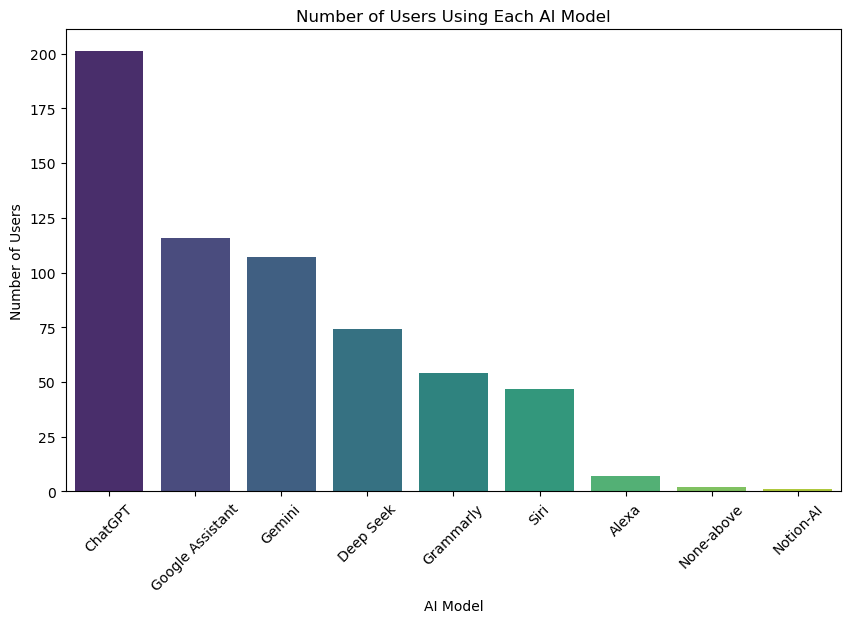

In [43]:
# List of AI model columns (binary 0/1)
ai_models = [
    "Alexa", "ChatGPT", "Deep Seek", "Gemini", "Google Assistant",
    "Grammarly", "None-above", "Notion-AI", "Siri"
]

# Count of users using each model
model_counts = df[ai_models].sum().sort_values(ascending=False)

# Convert to dataframe for plotting
plot_df = model_counts.reset_index()
plot_df.columns = ["AI_Model", "User_Count"]

# Bar plot
plt.figure(figsize=(10,6))
sns.barplot(x="AI_Model", y="User_Count", data=plot_df, palette="viridis")
plt.title("Number of Users Using Each AI Model")
plt.ylabel("Number of Users")
plt.xlabel("AI Model")
plt.xticks(rotation=45)
plt.show()

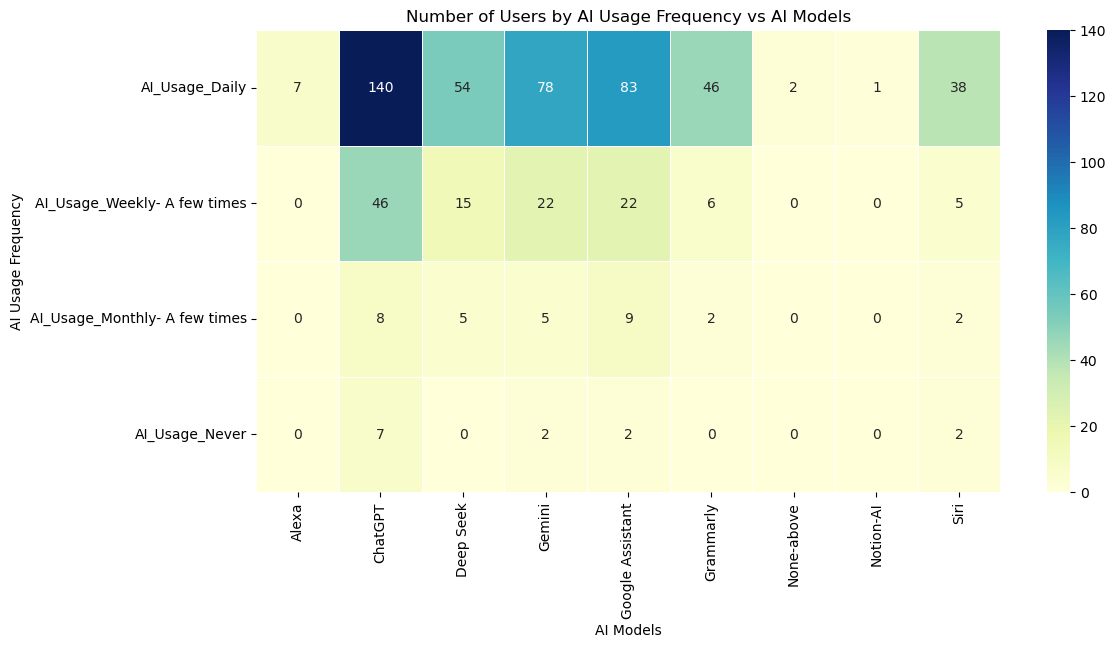

In [45]:
# AI usage columns
usage_cols = [
    "AI_Usage_Daily",
    "AI_Usage_Weekly- A few times",
    "AI_Usage_Monthly- A few times",
    "AI_Usage_Never"
]

# AI model columns
ai_models = [
    "Alexa", "ChatGPT", "Deep Seek", "Gemini", "Google Assistant",
    "Grammarly", "None-above", "Notion-AI", "Siri"
]

# Create a matrix of counts: usage frequency vs AI model
heatmap_data = pd.DataFrame(index=usage_cols, columns=ai_models)

for usage in usage_cols:
    subset = df[df[usage] == 1]
    counts = subset[ai_models].sum()
    heatmap_data.loc[usage] = counts

# Convert to numeric
heatmap_data = heatmap_data.astype(int)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Number of Users by AI Usage Frequency vs AI Models")
plt.ylabel("AI Usage Frequency")
plt.xlabel("AI Models")
plt.show()

In [46]:
# Predictor
X = df[['Age', 'Gender_Female', 'Gender_Male',
       'AI_Knowledge_Beginner', 'AI_Knowledge_Expert',
       'AI_Knowledge_Intermediate', 'AI_Usage_Daily', 'Alexa', 'ChatGPT', 'Deep Seek',
       'Gemini', 'Google Assistant', 'Grammarly', 'None-above', 'Notion-AI',
       'Siri']]
X = sm.add_constant(X)

In [47]:
# Outcome: AI Concern (AI_Concern_Yes)
y_concern = df["AI_Concern_No"]

In [48]:
model_concern = sm.Logit(y_concern, X).fit()
print("\n=== CONCERN MODEL ===")
print(model_concern.summary())

         Current function value: 0.131191
         Iterations: 35

=== CONCERN MODEL ===
                           Logit Regression Results                           
Dep. Variable:          AI_Concern_No   No. Observations:                  220
Model:                          Logit   Df Residuals:                      204
Method:                           MLE   Df Model:                           15
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.2905
Time:                        01:06:52   Log-Likelihood:                -28.862
converged:                      False   LL-Null:                       -40.680
Covariance Type:            nonrobust   LLR p-value:                   0.07155
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.2550        nan        nan        nan         nan         n

C:\Users\ashik\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
